# Restaurant Orders Dataset

# Dataset Summary

This dataset contains restaurant order transaction data collected from multiple branches.
It includes information about orders, customers, menu items, quantities, prices, discounts, payment methods, preparation times, customer ratings, and order status.
The dataset is designed to simulate real-world restaurant operations and includes realistic business scenarios such as cancelled orders with missing customer ratings.
It is ideal for practicing **data cleaning**, **data validation**, **feature engineering**, **exploratory data analysis (EDA)**, and building **Business Intelligence (BI)** dashboards.


# Data Description

| Column Name      | Description                                                                                                            | Example Values                    |
| ---------------- | ---------------------------------------------------------------------------------------------------------------------- | --------------------------------- |
| Order_ID         | A unique identifier for each order. Always present and unique.                                                         | ORD19639                          |
| Order_Date       | The date when the order was placed. Used for time-based analysis.                                                      | 2025-01-01                        |
| Day_Name         | The day of the week corresponding to the order date.                                                                   | Wednesday, Friday                 |
| Month            | The month in which the order was placed.                                                                               | January, February                 |
| Order_Time       | The time when the order was placed.                                                                                    | 09:00:42, 18:35:10                |
| Time_Period      | The meal period based on the order time.                                                                               | Breakfast, Lunch, Dinner          |
| Branch           | The restaurant branch where the order was placed.                                                                      | Downtown, Mall Branch, Airport    |
| Waiter_Name      | The staff member responsible for serving the order.                                                                    | Ahmed Hassan, Omar Ali            |
| Customer_Type    | Indicates whether the customer is new or returning.                                                                    | New, Returning                    |
| Dine_Type        | The order fulfillment method.                                                                                          | Dine In, Takeaway, Delivery       |
| Item_Category    | The category of the ordered item.                                                                                      | Pizza, Burger, Drinks, Dessert    |
| Item_Name        | The name of the ordered menu item.                                                                                     | Veggie Pizza, Cola, Brownie       |
| Quantity         | The number of items ordered.                                                                                           | 1, 2, 4                           |
| Unit_Price       | The price of a single item before any discount.                                                                        | 40, 170, 215                      |
| Discount         | The discount applied to the order. May be zero if no discount is applied.                                              | 0, 20, 50                         |
| Total_Sales      | The final order amount after applying the discount.                                                                    | 170, 380, 450                     |
| Payment_Method   | The payment method used by the customer.                                                                               | Cash, Credit Card, Digital Wallet |
| Preparation_Time | The time required to prepare the order (in minutes).                                                                   | 5, 18, 26                         |
| Customer_Rating  | The customer's rating of the completed order on a scale from 1 to 5. Missing values are expected for cancelled orders. | 3, 4, 5                           |
| Order_Status     | The final status of the order.                                                                                         | Completed, Cancelled              |


## Cleaning Steps Suggestions

1. **Handle Missing Values:**

   * Check for missing values across all columns.
   * Keep missing values in **Customer_Rating** if the corresponding **Order_Status** is **Cancelled**, as these are expected and represent valid business logic.
   * Investigate any missing values in other columns and handle them appropriately (e.g., fill with mode, median, or remove records if necessary).

2. **Handle Duplicate Records:**

   * Check for duplicate rows and duplicate **Order_ID** values.
   * Remove duplicate records while ensuring each order remains unique.

3. **Validate Data Integrity:**

   * Ensure **Order_ID** is unique.
   * Verify that **Quantity**, **Unit_Price**, and **Preparation_Time** are greater than zero.
   * Ensure **Discount** is not negative.
   * Validate that **Customer_Rating** falls between **1 and 5**.
   * Verify that **Total_Sales** is correctly calculated based on **Quantity**, **Unit_Price**, and **Discount**.

4. **Validate Date and Time:**

   * Convert **Order_Date** to a standard datetime format.
   * Convert **Order_Time** to a time format.
   * Verify that **Day_Name** matches the actual day derived from **Order_Date**.
   * Verify that **Month** matches the month extracted from **Order_Date**.
   * Validate that **Time_Period** (Breakfast, Lunch, Dinner) is consistent with **Order_Time**.

5. **Handle Outliers:**

   * Detect unusual values in numeric columns such as **Quantity**, **Unit_Price**, **Total_Sales**, and **Preparation_Time** using statistical methods (e.g., IQR).
   * Review extreme values before deciding whether to keep or remove them.

6. **Feature Engineering:**

   * Create additional analytical features such as:

     * **Gross_Sales** (Quantity × Unit_Price)
     * **Discount_Amount**
     * **Order_Hour**
     * **Is_Weekend**
     * **Meal_Size** (Small, Medium, Large)
     * **Price_Category** (Low, Medium, High)

7. **Final Data Validation:**

   * Confirm that all data types are correct.
   * Ensure there are no unexpected missing values or inconsistencies.
   * Export the cleaned dataset for further analysis and dashboard development.


# Importing Libraries and Loading the Dataset

In [776]:
import pandas as pd
import numpy as np

pd.set_option("display.max_rows", None)

# Load Dataset

In [777]:
path=r"D:\instructor\DINA\new mat 2026\New folder\Restaurant Sales\New folder\Restaurant_Orders.csv"

df = pd.read_csv(path)

# Exploring and Understanding the Dataset

In [778]:
print("Dataset dimensions:")
df.shape

Dataset dimensions:


(19197, 20)

In [779]:
print("First Rows:")
df.head()

First Rows:


,Order_ID,Order_Date,Day_Name,Month,Order_Time,Time_Period,Branch,Waiter_Name,Customer_Type,Dine_Type,Item_Category,Item_Name,Quantity,Unit_Price,Discount,Total_Sales,Payment_Method,Preparation_Time,Customer_Rating,Order_Status
0,ORD19639,1/1/2025,Wednesday,January,9:00:42,Breakfast,Mall Branch,Omar Ali,Returning,Takeaway,Pizza,Veggie Pizza,2,190,0,380.0,Credit Card,26,3,Completed
1,ORD05171,1/1/2025,Wednesday,January,9:06:39,Breakfast,East Side,Youssef Mohamed,New,Dine In,Burger,Classic Burger,1,170,0,170.0,Digital Wallet,16,5,Completed
2,ORD07831,1/1/2025,Wednesday,January,10:28:16,Breakfast,Nasr City,Mohamed Tarek,Returning,Dine In,Pasta,Spicy Pasta,1,215,0,215.0,Cash,15,5,Completed
3,ORD03059,1/1/2025,Wednesday,January,10:28:35,Breakfast,Mall Branch,Omar Ali,Returning,Delivery,Dessert,Brownie,2,85,0,170.0,Cash,9,5,Completed
4,ORD11636,1/1/2025,Wednesday,January,10:38:33,Breakfast,East Side,Youssef Mohamed,Returning,Delivery,Dessert,Chocolate Cake,2,95,0,190.0,Cash,12,4,Completed


# Dataset Overview

The dataset consists of **20,200 records** and **20 columns**, representing restaurant order transactions collected from multiple branches.
It captures information about order details, customers, menu items, pricing, discounts, payment methods, preparation time, customer ratings, and order status.
The dataset reflects real-world restaurant operations and includes business scenarios such as **cancelled orders**, where missing customer ratings are expected.
It is ideal for practicing **data cleaning**, **data validation**, **feature engineering**, **exploratory data analysis (EDA)**, and preparing data for **Business Intelligence (BI)** dashboards.

| Column Type            | Count | Examples                                                  |
| ---------------------- | ----: | --------------------------------------------------------- |
| Numerical (`int64`)    |     4 | Quantity, Unit_Price, Discount, Preparation_Time          |
| Numerical (`float64`)  |     2 | Total_Sales, Customer_Rating                              |
| Categorical (`object`) |    14 | Order_ID, Branch, Item_Name, Payment_Method, Order_Status |

**Missing values:**

* Present only in **Customer_Rating**.
* Missing ratings are expected for **Cancelled** orders and therefore represent valid business logic rather than data quality issues.

**Data types include:**

* `object` (categorical/text): **14 columns**
* `int64` (integer): **4 columns**
* `float64` (numeric): **2 columns**
* `Order_Date` and `Order_Time` should be converted to appropriate **datetime** formats during the data cleaning process.

This dataset is ideal for tasks such as **data type correction**, **data quality validation**, **missing value analysis**, **feature engineering**, **outlier detection**, and **EDA** before building analytical dashboards.


In [780]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19197 entries, 0 to 19196
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          19197 non-null  object 
 1   Order_Date        19197 non-null  object 
 2   Day_Name          19197 non-null  object 
 3   Month             19197 non-null  object 
 4   Order_Time        19197 non-null  object 
 5   Time_Period       19197 non-null  object 
 6   Branch            19197 non-null  object 
 7   Waiter_Name       19197 non-null  object 
 8   Customer_Type     19197 non-null  object 
 9   Dine_Type         19197 non-null  object 
 10  Item_Category     19197 non-null  object 
 11  Item_Name         19197 non-null  object 
 12  Quantity          19197 non-null  int64  
 13  Unit_Price        19197 non-null  int64  
 14  Discount          19197 non-null  int64  
 15  Total_Sales       19197 non-null  float64
 16  Payment_Method    19197 non-null  object

In [781]:
categorical_cols = df.select_dtypes(include=['object']).columns

# Categorical Columns

print(" --- Categorical Columns Analysis ---\n")

for col in categorical_cols:
    unique_vals = df[col].unique()
    num_unique = df[col].nunique()

    print(f"Column: {col}")
    print(f"Number of Unique Values: {num_unique}")
    print(f"Unique Values: {list(unique_vals)}\n")

 --- Categorical Columns Analysis ---

Column: Order_ID
Number of Unique Values: 19009
Unique Values: ['ORD19639', 'ORD05171', 'ORD07831', 'ORD03059', 'ORD11636', 'ORD19833', 'ORD08560', 'ORD08396', 'ORD08847', 'ORD10494', 'ORD19217', 'ORD14070', 'ORD18548', 'ORD05488', 'ORD07380', 'ORD12222', 'ORD14881', 'ORD11062', 'ORD06517', 'ORD04626', 'ORD17473', 'ORD08173', 'ORD03562', 'ORD19119', 'ORD19576', 'ORD13256', 'ORD12114', 'ORD18835', 'ORD04174', 'ORD07010', 'ORD18388', 'ORD04473', 'ORD10389', 'ORD18483', 'ORD15762', 'ORD09242', 'ORD18576', 'ORD18391', 'ORD12443', 'ORD00681', 'ORD10736', 'ORD01191', 'ORD11976', 'ORD07613', 'ORD13598', 'ORD04509', 'ORD00594', 'ORD01306', 'ORD17532', 'ORD15778', 'ORD05413', 'ORD05940', 'ORD02452', 'ORD04517', 'ORD13346', 'ORD10668', 'ORD09525', 'ORD10779', 'ORD00646', 'ORD07668', 'ORD06254', 'ORD01715', 'ORD13588', 'ORD18852', 'ORD16317', 'ORD18978', 'ORD14383', 'ORD18248', 'ORD03067', 'ORD14051', 'ORD00903', 'ORD11997', 'ORD15803', 'ORD04555', 'ORD01002

# Duplicated values

In [782]:
print("Number of duplicate rows:")
df.duplicated().sum()

Number of duplicate rows:


np.int64(188)

In [783]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Data Type Conversion

In [784]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [785]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19009 entries, 0 to 19196
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          19009 non-null  object        
 1   Order_Date        19009 non-null  datetime64[ns]
 2   Day_Name          19009 non-null  object        
 3   Month             19009 non-null  object        
 4   Order_Time        19009 non-null  object        
 5   Time_Period       19009 non-null  object        
 6   Branch            19009 non-null  object        
 7   Waiter_Name       19009 non-null  object        
 8   Customer_Type     19009 non-null  object        
 9   Dine_Type         19009 non-null  object        
 10  Item_Category     19009 non-null  object        
 11  Item_Name         19009 non-null  object        
 12  Quantity          19009 non-null  int64         
 13  Unit_Price        19009 non-null  int64         
 14  Discount          19009 non

# missing values

In [786]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Day_Name            0
Month               0
Order_Time          0
Time_Period         0
Branch              0
Waiter_Name         0
Customer_Type       0
Dine_Type           0
Item_Category       0
Item_Name           0
Quantity            0
Unit_Price          0
Discount            0
Total_Sales         0
Payment_Method      0
Preparation_Time    0
Customer_Rating     0
Order_Status        0
dtype: int64

# Data Validation

In [787]:
# Quantity
(df["Quantity"] <= 0).sum()

np.int64(0)

In [788]:
# Unit Price
(df["Unit_Price"] <= 0).sum()

np.int64(0)

In [789]:
# Discount
(df["Discount"] < 0).sum()

np.int64(0)

In [790]:
# Check if Total_Sales is correct: True if calculated Total_Sales is close, else False
df["Sales_Validation"] = np.where(
    df["Quantity"].notna() &
    df["Unit_Price"].notna() &
    df["Discount"].notna() &
    df["Total_Sales"].notna() &
    (
        np.isclose(
            df["Total_Sales"],
            (df["Quantity"] * df["Unit_Price"]) * (1 - df["Discount"] / 100),
            atol=0.05
        )
    ),
    True,
    False
)

df["Sales_Validation"].value_counts()

Sales_Validation
True    19009
Name: count, dtype: int64

In [791]:
df.drop(columns=["Sales_Validation"], inplace=True)

## Numerical Feature Insights

* **Unit_Price**: The average price per menu item is approximately **163.63**, with a median price of **190**.

  Prices range from **25** to **250**, while **50% of menu items are priced between 95 and 220**, reflecting a balanced pricing structure across the restaurant menu.

* **Quantity**: Customers order an average of approximately **1.94 items per order** (**median = 2**).

  Order quantities range from **1** to **5 items**, with **50% of orders containing between 1 and 3 items**, indicating that most customers place relatively small orders.

* **Discount**: Discounts are generally low, with an average of approximately **2.92%**.

  The median discount is **0%**, meaning that more than half of the orders receive no discount, while the maximum discount reaches **15%**.

* **Total_Sales**: The average order value is approximately **308.33** (**median = 220**).

  Order totals range from **21.25** to **1250**, with **50% of orders falling between 170 and 425**, indicating a mix of low-value and high-value purchases.

* **Preparation_Time**: Orders require an average preparation time of approximately **16.38 minutes** (**median = 17 minutes**).

  Preparation times range from **2** to **35 minutes**, with **50% of orders prepared within 11 to 22 minutes**, suggesting relatively consistent kitchen performance.

* **Customer_Rating**: Completed orders receive an average customer rating of approximately **3.65 out of 5** (**median = 4**).

  Ratings range from **1** to **5**, with **50% of ratings between 3 and 4**, indicating generally positive customer satisfaction.


In [792]:
print("Descriptive statistics:")
df.describe()

Descriptive statistics:


,Order_Date,Quantity,Unit_Price,Discount,Total_Sales,Preparation_Time,Customer_Rating
count,19009,19009.000000,19009.000000,19009.000000,19009.000000,19009.000000,19009.000000
mean,2025-07-03 01:35:31.516650240,1.940449,163.633279,2.920459,308.334368,16.375401,3.645905
min,2025-01-01 00:00:00,1.000000,25.000000,0.000000,21.250000,2.000000,1.000000
25%,2025-04-02 00:00:00,1.000000,95.000000,0.000000,170.000000,11.000000,3.000000
50%,2025-07-04 00:00:00,2.000000,190.000000,0.000000,220.000000,17.000000,4.000000
75%,2025-10-03 00:00:00,3.000000,220.000000,5.000000,425.000000,22.000000,4.000000
max,2025-12-31 00:00:00,5.000000,250.000000,15.000000,1250.000000,35.000000,5.000000
std,NaN,1.075109,67.537456,4.627574,224.610386,7.065408,1.122298


## Categorical Feature Insights

* **Order_ID**: The dataset contains **19,009 unique order IDs**, confirming that each record represents a unique order with no duplicate identifiers.

* **Day_Name**: Orders are distributed across all **7 days of the week**, with **Monday** having the highest number of completed orders (**2,810 orders**).

* **Month**: The dataset covers all **12 months** of the year, with **March** containing the highest number of completed orders (**1,676 orders**), indicating year-round transaction coverage.

* **Time_Period**: Orders are categorized into **Breakfast**, **Lunch**, and **Dinner**. **Dinner** is the busiest period, accounting for **9,430 completed orders**.

* **Branch**: The restaurant operates across **6 branches**. **Downtown** records the highest number of completed orders (**5,234 orders**), making it the busiest branch in the dataset.

* **Waiter_Name**: The dataset includes **12 waiters**. **Ahmed Hassan** handled the highest number of completed orders (**2,625 orders**).

* **Customer_Type**: There are **2 customer types**: **New** and **Returning**. Returning customers represent the majority, with **13,630 completed orders**, indicating strong customer retention.

* **Dine_Type**: Orders are classified into **Dine In**, **Takeaway**, and **Delivery**. **Dine In** is the most common order type, with **9,502 completed orders**.

* **Item_Category**: The menu consists of **5 item categories**. **Pizza** is the most frequently ordered category, with **5,714 completed orders**.

* **Item_Name**: The dataset contains **20 menu items**. **Margherita** is the most ordered item, appearing in **2,067 completed orders**.

* **Payment_Method**: Customers use **3 payment methods**. **Credit Card** is the most frequently used payment method, with **7,698 completed transactions**.

* **Order_Status**: After the data cleaning process, the dataset contains only **Completed** orders, indicating that cancelled orders were removed before analysis.


In [793]:
df.describe(include='object')

,Order_ID,Day_Name,Month,Order_Time,Time_Period,Branch,Waiter_Name,Customer_Type,Dine_Type,Item_Category,Item_Name,Payment_Method,Order_Status
count,19009,19009,19009,19009,19009,19009,19009,19009,19009,19009,19009,19009,19009
unique,19009,7,12,15984,3,6,12,2,3,5,20,3,1
top,ORD06884,Monday,March,8:54:50,Dinner,Downtown,Ahmed Hassan,Returning,Dine In,Pizza,Margherita,Credit Card,Completed
freq,1,2810,1676,5,9430,5234,2625,13630,9502,5714,2067,7698,19009


# Feature Engineering

In [794]:
# Revenue Before Discount
df["Gross_Sales"] = (
    df["Quantity"] *
    df["Unit_Price"]
)

In [795]:
# Discount Amount
df["Discount_Amount"] = (
    df["Gross_Sales"] -
    df["Total_Sales"]
)

In [796]:
# Average Item Price
df["Average_Item_Price"] = (
    df["Total_Sales"] /
    df["Quantity"]
)

In [797]:
df.head()

,Order_ID,Order_Date,Day_Name,Month,Order_Time,Time_Period,Branch,Waiter_Name,Customer_Type,Dine_Type,...,Unit_Price,Discount,Total_Sales,Payment_Method,Preparation_Time,Customer_Rating,Order_Status,Gross_Sales,Discount_Amount,Average_Item_Price
0,ORD19639,2025-01-01,Wednesday,January,9:00:42,Breakfast,Mall Branch,Omar Ali,Returning,Takeaway,...,190,0,380.0,Credit Card,26,3,Completed,380,0.0,190.0
1,ORD05171,2025-01-01,Wednesday,January,9:06:39,Breakfast,East Side,Youssef Mohamed,New,Dine In,...,170,0,170.0,Digital Wallet,16,5,Completed,170,0.0,170.0
2,ORD07831,2025-01-01,Wednesday,January,10:28:16,Breakfast,Nasr City,Mohamed Tarek,Returning,Dine In,...,215,0,215.0,Cash,15,5,Completed,215,0.0,215.0
3,ORD03059,2025-01-01,Wednesday,January,10:28:35,Breakfast,Mall Branch,Omar Ali,Returning,Delivery,...,85,0,170.0,Cash,9,5,Completed,170,0.0,85.0
4,ORD11636,2025-01-01,Wednesday,January,10:38:33,Breakfast,East Side,Youssef Mohamed,Returning,Delivery,...,95,0,190.0,Cash,12,4,Completed,190,0.0,95.0


# Retail Sales Data Analysis

In [798]:
# 1. Total Revenue
total_revenue = df['Total_Sales'].sum()
print("1. Total Revenue:", total_revenue)


1. Total Revenue: 5861128.0


In [799]:
# 2. Item with the Highest Total Sales
item_sales = (
    df.groupby('Item_Name')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)
print("\n2. Item with Highest Total Sales:\n", item_sales)



2. Item with Highest Total Sales:
 Item_Name
Margherita           709533.00
Pepperoni            687731.00
Alfredo Pasta        545202.00
BBQ Chicken          527262.50
Classic Burger       476731.00
Bolognese Pasta      469931.00
Cheese Burger        451335.50
Double Burger        372128.50
Veggie Pizza         303069.00
White Sauce Pasta    284730.00
Spicy Pasta          218225.00
Chicken Burger       208359.00
Cheesecake           132547.50
Chocolate Cake       105711.25
Cola                 102076.00
Orange Juice          91047.00
Lemon Mint            75414.00
Brownie               53150.50
Ice Cream             25105.50
Water                 21838.75
Name: Total_Sales, dtype: float64


In [800]:
# 3. Average Quantity per Order
avg_quantity = df['Quantity'].mean()
print("\n3. Average Quantity per Order:", round(avg_quantity, 2))



3. Average Quantity per Order: 1.94


In [801]:
# 4. Number of Orders by Payment Method
payment_counts = df['Payment_Method'].value_counts()
print("\n4. Orders by Payment Method:\n", payment_counts)



4. Orders by Payment Method:
 Payment_Method
Credit Card       7698
Cash              5670
Digital Wallet    5641
Name: count, dtype: int64


In [802]:
# 5. Branch with the Highest Number of Orders
most_common_branch = df['Branch'].mode()[0]
print("\n5. Most Common Branch:", most_common_branch)



5. Most Common Branch: Downtown


In [803]:
# 6. Total Sales by Month
monthly_sales = (
    df.groupby('Month')['Total_Sales']
      .sum()
      .sort_values(ascending=False)
)
print("\n6. Total Sales by Month:\n", monthly_sales)


6. Total Sales by Month:
 Month
August       515874.25
March        513645.25
October      510182.25
December     501756.75
November     500417.25
January      496077.25
May          495050.75
September    489278.75
July         487763.25
April        460914.75
June         456866.25
February     433301.25
Name: Total_Sales, dtype: float64


# Outlier Detection

In [804]:
# Outlier Detection for Unit_Price

# Calculate the first quartile (Q1)
Q1 = df["Unit_Price"].quantile(0.25)

# Calculate the third quartile (Q3)
Q3 = df["Unit_Price"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Calculate the lower and upper limits
lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

# Find outliers
outliers = df[
    (df["Unit_Price"] < lower) |
    (df["Unit_Price"] > upper)
]

# Display the number of outliers
print("Number of Outliers:", len(outliers))

# Display the outlier rows
outliers

Number of Outliers: 0


,Order_ID,Order_Date,Day_Name,Month,Order_Time,Time_Period,Branch,Waiter_Name,Customer_Type,Dine_Type,...,Unit_Price,Discount,Total_Sales,Payment_Method,Preparation_Time,Customer_Rating,Order_Status,Gross_Sales,Discount_Amount,Average_Item_Price


# Save Data

In [805]:
df.to_csv("Cleaned_Data.csv", index=False)

# visualization

In [806]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\E.J.S\AppData\Local\Temp\ipykernel_18216\1630345564.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


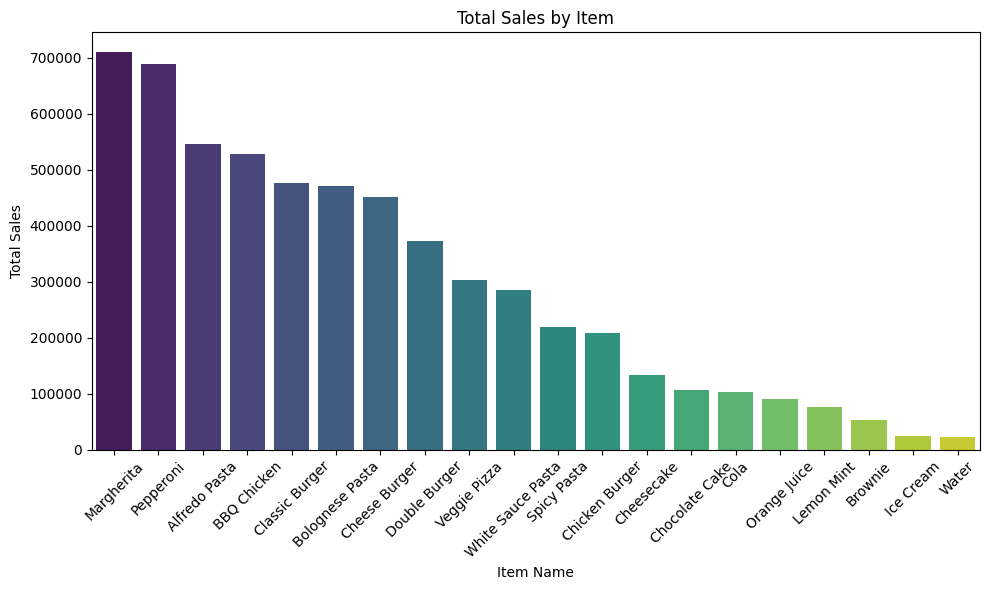

In [807]:
# 1. Total Sales by Item

item_sales = (
    df.groupby("Item_Name")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=item_sales.index,
    y=item_sales.values,
    palette="viridis"
)

plt.title("Total Sales by Item")
plt.xlabel("Item Name")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

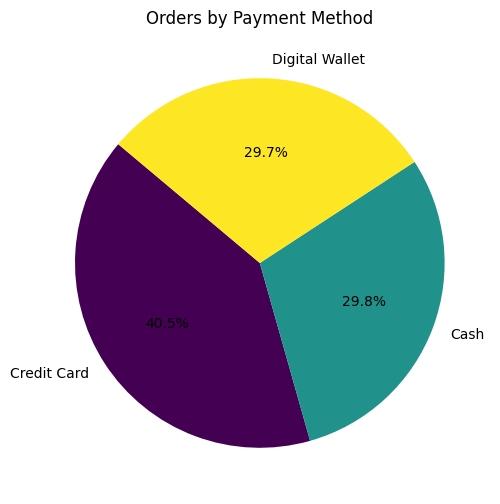

In [808]:
# 2. Orders by Payment Method

payment_counts = df["Payment_Method"].value_counts()

colors = ["#440154", "#21918C", "#FDE725"]

plt.figure(figsize=(6,6))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)

plt.title("Orders by Payment Method")

plt.show()

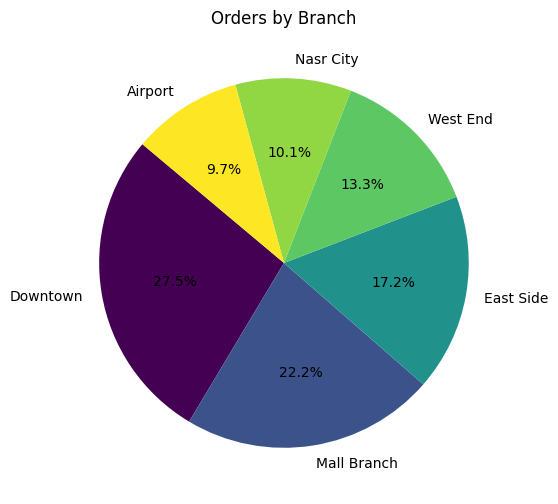

In [809]:
# 3. Orders by Branch

branch_counts = df["Branch"].value_counts()

colors = ["#440154", "#3B528B", "#21918C", "#5DC863", "#90D743", "#FDE725"]

plt.figure(figsize=(6,6))

plt.pie(
    branch_counts,
    labels=branch_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)

plt.title("Orders by Branch")

plt.show()

# Star Schema

# Fact_Orders

| Column Name         | Description                          |
| ------------------- | ------------------------------------ |
| Order_ID            | Business Order ID                    |
| Order_Date          | Order date                           |
| Day_Name            | Day of the week                      |
| Month               | Month name                           |
| Order_Time          | Order time                           |
| Time_Period         | Meal period                          |
| Branch_Key          | Foreign Key → Dim_Branch             |
| Waiter_Key          | Foreign Key → Dim_Waiter             |
| Category_Key        | Category Key                         |
| Item_Key            | Foreign Key → Dim_Item               |
| Customer_Type       | Customer type                        |
| Dine_Type           | Order type                           |
| Quantity            | Number of items ordered              |
| Discount            | Discount percentage (%)              |
| Gross_Sales         | Quantity × Unit Price                |
| Discount_Amount     | Discount value                       |
| Total_Sales         | Final sales after discount           |
| Payment_Method      | Payment method                       |
| Preparation_Time    | Order preparation time (minutes)     |
| Customer_Rating     | Customer rating (1–5)                |
| Order_Status        | Final order status                   |
| Average_Item_Price  | Average selling price per item       |

---

# Dim_Branch

| Column Name | Description       |
| ------------| ----------------- |
| Branch_Key  | Primary Key       |
| Branch       | Branch name       |

---

# Dim_Waiter

| Column Name | Description                     |
| ------------| ------------------------------- |
| Waiter_Key  | Primary Key                     |
| Waiter_Name | Waiter name                     |
| Branch_Key  | Foreign Key → Dim_Branch        |

---

# Dim_Item

| Column Name   | Description                 |
| ------------- | --------------------------- |
| Category_Key  | Category Key                |
| Item_Category | Menu category               |
| Item_Key      | Primary Key                 |
| Item_Name     | Menu item name              |
| Unit_Price    | Price of one item           |

---

# Key Relationships

| Fact Table  | Dimension Table | Key         |
| ------------| ----------------| ----------- |
| Fact_Orders | Dim_Branch      | Branch_Key  |
| Fact_Orders | Dim_Waiter      | Waiter_Key  |
| Fact_Orders | Dim_Item        | Item_Key    |

### Foreign Keys in Fact_Orders

- `Branch_Key`
- `Waiter_Key`
- `Category_Key`
- `Item_Key`

## Dim_Branch

In [810]:
df["Branch"].unique()

array(['Mall Branch', 'East Side', 'Nasr City', 'Airport', 'Downtown',
       'West End'], dtype=object)

In [811]:
branch_dict = {
    "Mall Branch": 1,
    "East Side": 2,
    "Nasr City": 3,
    "Airport": 4,
    "Downtown": 5,
    "New Cairo": 6,
    "West End":7
}

df["Branch_Key"] = df["Branch"].map(branch_dict)

In [812]:
dim_branch = (
    df[
        [
            "Branch_Key",
            "Branch",
        ]
    ]
    .drop_duplicates()
    .sort_values("Branch_Key")
    .reset_index(drop=True)
)

dim_branch

,Branch_Key,Branch
0,1,Mall Branch
1,2,East Side
2,3,Nasr City
3,4,Airport
4,5,Downtown
5,7,West End


## Dim_Waiter

In [813]:
df["Waiter_Name"].unique()

array(['Omar Ali', 'Youssef Mohamed', 'Mohamed Tarek', 'Aya Samir',
       'Heba Ahmed', 'Ahmed Hassan', 'Mona Adel', 'Khaled Ibrahim',
       'Sara Mostafa', 'Nour Ahmed', 'Salma Hany', 'Ali Mahmoud'],
      dtype=object)

In [814]:
waiter_dict = {
    "Omar Ali": 1,
    "Youssef Mohamed": 2,
    "Mohamed Tarek": 3,
    "Aya Samir": 4,
    "Heba Ahmed": 5,
    "Ahmed Hassan": 6,
    "Mona Adel": 7,
    "Khaled Ibrahim": 8,
    "Sara Mostafa": 9,
    "Nour Ahmed": 10,
    "Salma Hany": 11,
    "Ali Mahmoud": 12
}

df["Waiter_Key"] = df["Waiter_Name"].map(waiter_dict)

In [815]:
dim_waiter = (
    df[
        [
            "Waiter_Key",
            "Waiter_Name",
            "Branch_Key"
        ]
    ]
    .drop_duplicates()
    .sort_values("Waiter_Key")
    .reset_index(drop=True)
)

dim_waiter

,Waiter_Key,Waiter_Name,Branch_Key
0,1,Omar Ali,1
1,2,Youssef Mohamed,2
2,3,Mohamed Tarek,3
3,4,Aya Samir,3
4,5,Heba Ahmed,4
5,6,Ahmed Hassan,5
6,7,Mona Adel,5
7,8,Khaled Ibrahim,7
8,9,Sara Mostafa,1
9,10,Nour Ahmed,2


## Dim_Item

In [816]:
df["Item_Category"].unique()

array(['Pizza', 'Burger', 'Pasta', 'Dessert', 'Drinks'], dtype=object)

In [817]:
category_dict = {
    "Pizza": 1,
    "Burger": 2,
    "Pasta": 3,
    "Dessert": 4,
    "Drinks": 5
}

df["Category_Key"] = df["Item_Category"].map(category_dict)

In [818]:
df["Item_Name"].unique()

array(['Veggie Pizza', 'Classic Burger', 'Spicy Pasta', 'Brownie',
       'Chocolate Cake', 'Cola', 'Cheesecake', 'White Sauce Pasta',
       'Cheese Burger', 'Double Burger', 'Water', 'Chicken Burger',
       'BBQ Chicken', 'Margherita', 'Lemon Mint', 'Alfredo Pasta',
       'Orange Juice', 'Bolognese Pasta', 'Pepperoni', 'Ice Cream'],
      dtype=object)

In [819]:
product_dict = {
    "Veggie Pizza": 1,
    "Classic Burger": 2,
    "Spicy Pasta": 3,
    "Brownie": 4,
    "Chocolate Cake": 5,
    "Cola": 6,
    "Cheesecake": 7,
    "White Sauce Pasta": 8,
    "Cheese Burger": 9,
    "Double Burger": 10,
    "Water": 11,
    "Chicken Burger": 12,
    "BBQ Chicken": 13,
    "Margherita": 14,
    "Lemon Mint": 15,
    "Alfredo Pasta": 16,
    "Orange Juice": 17,
    "Bolognese Pasta": 18,
    "Pepperoni": 19,
    "Ice Cream": 20
}

df["Item_Key"] = df["Item_Name"].map(product_dict)

In [820]:
dim_item = (
    df[
        [
            "Category_Key",
            "Item_Category",
            "Item_Key",
            "Item_Name",
            "Unit_Price"
        ]
    ]
    .drop_duplicates()
    .sort_values("Category_Key")
    .reset_index(drop=True)
)

dim_item

,Category_Key,Item_Category,Item_Key,Item_Name,Unit_Price
0,1,Pizza,1,Veggie Pizza,190
1,1,Pizza,14,Margherita,180
2,1,Pizza,13,BBQ Chicken,250
3,1,Pizza,19,Pepperoni,220
4,2,Burger,10,Double Burger,230
5,2,Burger,9,Cheese Burger,190
6,2,Burger,12,Chicken Burger,180
7,2,Burger,2,Classic Burger,170
8,3,Pasta,8,White Sauce Pasta,200
9,3,Pasta,16,Alfredo Pasta,210


## Remove Text Columns from Fact Table

In [821]:
df.drop(
    columns=[
        "Branch",
        "Waiter_Name",
        "Item_Category",
        "Item_Name"
    ],
    inplace=True
)

df.head()

,Order_ID,Order_Date,Day_Name,Month,Order_Time,Time_Period,Customer_Type,Dine_Type,Quantity,Unit_Price,...,Preparation_Time,Customer_Rating,Order_Status,Gross_Sales,Discount_Amount,Average_Item_Price,Branch_Key,Waiter_Key,Category_Key,Item_Key
0,ORD19639,2025-01-01,Wednesday,January,9:00:42,Breakfast,Returning,Takeaway,2,190,...,26,3,Completed,380,0.0,190.0,1,1,1,1
1,ORD05171,2025-01-01,Wednesday,January,9:06:39,Breakfast,New,Dine In,1,170,...,16,5,Completed,170,0.0,170.0,2,2,2,2
2,ORD07831,2025-01-01,Wednesday,January,10:28:16,Breakfast,Returning,Dine In,1,215,...,15,5,Completed,215,0.0,215.0,3,3,3,3
3,ORD03059,2025-01-01,Wednesday,January,10:28:35,Breakfast,Returning,Delivery,2,85,...,9,5,Completed,170,0.0,85.0,1,1,4,4
4,ORD11636,2025-01-01,Wednesday,January,10:38:33,Breakfast,Returning,Delivery,2,95,...,12,4,Completed,190,0.0,95.0,2,2,4,5


# save data

In [829]:
# Save Star Schema Tables

# Fact Table
df.to_csv("Fact_Orders.csv", index=False)

# Dimensions
dim_branch.to_csv("Dim_Branch.csv", index=False)
dim_waiter.to_csv("Dim_Waiter.csv", index=False)
dim_item.to_csv("Dim_Item.csv", index=False)

print("Star Schema tables saved successfully.")

Star Schema tables saved successfully.


# Encoding & Normalization

In [823]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [824]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Encoding

In [825]:
le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col])

# Normalization

In [826]:
# Normalization
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [827]:
df_encoded.head(5)

,Order_ID,Order_Date,Day_Name,Month,Order_Time,Time_Period,Customer_Type,Dine_Type,Quantity,Unit_Price,...,Preparation_Time,Customer_Rating,Order_Status,Gross_Sales,Discount_Amount,Average_Item_Price,Branch_Key,Waiter_Key,Category_Key,Item_Key
0,18661,0,6,4,15325,0,1,2,0.055392,0.390412,...,1.362250,-0.575535,0,0.270524,-0.477177,0.470813,-1.270928,-1.614053,-1.126406,-1.743678
1,4903,0,6,4,15384,0,0,1,-0.874771,0.094272,...,-0.053134,1.206570,0,-0.639706,-0.477177,0.168240,-0.774838,-1.311751,-0.435701,-1.568103
2,7438,0,6,4,302,0,1,1,-0.874771,0.760586,...,-0.194672,1.206570,0,-0.444657,-0.477177,0.849030,-0.278749,-1.009449,0.255004,-1.392528
3,2898,0,6,4,308,0,1,0,0.055392,-1.164322,...,-1.043902,1.206570,0,-0.639706,-0.477177,-1.117696,-1.270928,-1.614053,0.945709,-1.216953
4,11058,0,6,4,405,0,1,0,0.055392,-1.016252,...,-0.619287,0.315518,0,-0.553018,-0.477177,-0.966409,-0.774838,-1.311751,0.945709,-1.041378
